In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# DATA GENERATION

np.random.seed(42)

dates = pd.date_range(start="2015-01-01", periods=120, freq="M")
trend = np.linspace(100, 300, 120)
seasonality = 20 * np.sin(np.arange(120) * 2 * np.pi / 12)
noise = np.random.normal(0, 10, 120)

values = trend + seasonality + noise

df = pd.DataFrame({"date": dates, "demand": values})
df.set_index("date", inplace=True)

/tmp/ipykernel_9893/2771651810.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2015-01-01", periods=120, freq="M")


In [3]:
# TRAIN TEST SPLIT

train = df[:-12]
test = df[-12:]

In [4]:
# ARIMA MODEL

model = ARIMA(train["demand"], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


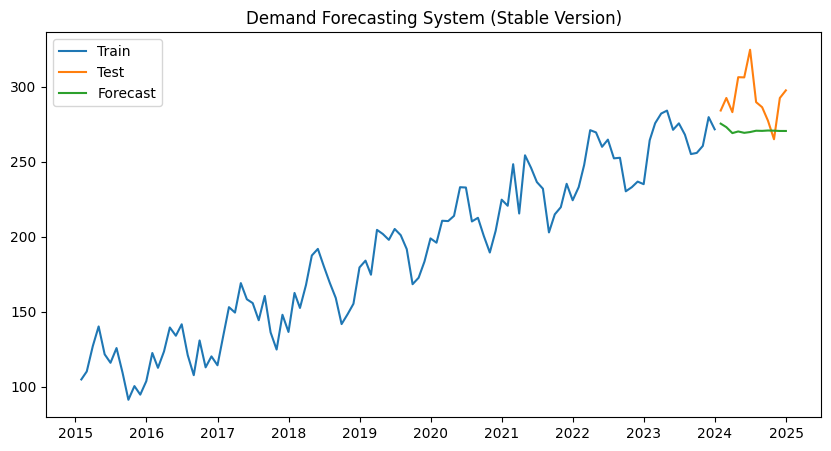

In [5]:
# PLOT

plt.figure(figsize=(10,5))
plt.plot(train.index, train["demand"], label="Train")
plt.plot(test.index, test["demand"], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("Demand Forecasting System (Stable Version)")
plt.show()

In [6]:
# ERROR METRIC

rmse = np.sqrt(np.mean((forecast - test["demand"])**2))
print("RMSE:", rmse)

RMSE: 26.17624878698389
